In [33]:
import numpy as np
import scipy as scipy
import scipy.special
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib import colors
import time
import uncertainties as error
import pandas as pd
np.random.seed(12345)

Part 1.)

In [34]:
#a.)

def H_0Likelyhood(MeasuredVelocity, H_0, Distance):
    exponent = -(MeasuredVelocity.n - (H_0*Distance))**2/(2*MeasuredVelocity.s**2)
    Likelyhood = 1/np.sqrt(2*np.pi*MeasuredVelocity.s**2) * np.exp(exponent)
    return(Likelyhood)

def Marginalization(MeasuredVelocity, H_0, Distance, H_0Prior):
    #now we integrate over H_0 to find p(Distance|Velocity)
    #This removes the nusiance parameter of H_0
    Posterior=[]
    for i in Distance:
        temp = np.trapz(H_0Likelyhood(MeasuredVelocity, H_0, i) * H_0Prior, x=H_0)
        Posterior.append(temp * DistancePrior[np.where(Distance=i)])
    
    print(Posterior)
    
    Posterior=np.array(Posterior) #to array
    Posterior /= np.trapz(Posterior, x=Distance) #normalize the posterior
    return(Posterior)

def GaussianPrior(x, Location, Width):
    GaussianValues = np.exp(-(x - Location)**2/(2*Width**2)) #makes the gaussian
    GaussianValues /= np.trapz(GaussianValues, x=x) #normalizes
    return(GaussianValues)

def UniformPrior(x, Start, End):
    #This is ez pz as we know the bounds already(it's what I'm feeding in for Start and End)
    return(np.zeros(np.shape(x)) + 1/(End-Start))

[1.4736461348785479e-199, 1.7640379791283134e-110, 6.092398686294358e-48, 3.378219919737947e-13, 6.723485630900461e-05, 5.69102323288534e-05, 4.446621082333353e-05, 1.1979317410461526e-05, 4.401109995151854e-12, 4.274777014836899e-27]


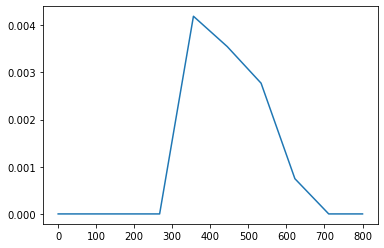

In [38]:
TestValuesDistance = np.linspace(0, 800, 10)
DistancePrior = UniformPrior(TestValuesDistance, 0, 800) #in Mpc

MeasuredVelocity = error.ufloat(30000, 1000) #in km/s

#This is part a specific
TestValuesH_0 = np.linspace(50, 90, 10)
H_0Prior = UniformPrior(TestValuesH_0, 50, 90) #in km/s/Mpc

Posterior = Marginalization(MeasuredVelocity, TestValuesH_0, TestValuesDistance, H_0Prior)

plt.plot(TestValuesDistance, Posterior)

Part 2.)

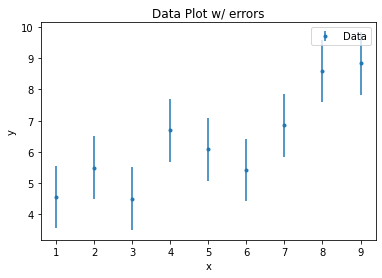

In [9]:
#This is my data input for the .txt files, may need to adjust the filepath
Data=pd.read_csv('HW7_Data/linear_data.txt', delim_whitespace=True)

plt.errorbar(Data['x'], Data['y'], yerr=Data['dy'], label='Data', linestyle='', fmt='.')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Data Plot w/ errors')
plt.show()

Optimized Slope: 0.4972999898640334
Optimized Yint: 3.850055579656032


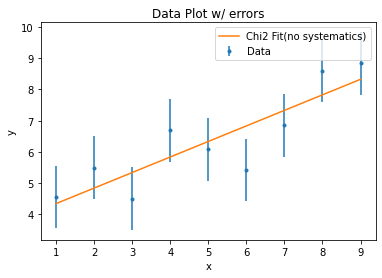

In [13]:
#a.)
#First thing we do is fit a linear function to this, assuming no systematics
#use chi2 minimization

#A frequentist approach. For this we will minimize chi2
def Chi2(Data, m, b):
    Chi2=np.sum((Data['y'] - (m*Data['x']+b))**2 / Data['dy']**2)
    return(Chi2)

def Chi2Minimizer(theta, Data):
    m, b = theta
    return Chi2(Data, m, b)

chi2minimized=scipy.optimize.minimize(Chi2Minimizer, x0=[0.5, 4], args=(Data,)) #some initial guesses
m_opt, b_opt = chi2minimized.x
print('Optimized Slope:', m_opt)
print('Optimized Yint:', b_opt)
plt.errorbar(Data['x'], Data['y'], yerr=Data['dy'], label='Data', linestyle='', fmt='.')
plt.plot(Data['x'], m_opt*Data['x'] + b_opt, label='Chi2 Fit(no systematics)')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Data Plot w/ errors')
plt.show()

In [ ]:
#b.)
#We include a distorting systematic of deltay = cx + dx^2
#If we let d=0, c=+/-0.05, recalculate the fits